# PCA for Iris Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


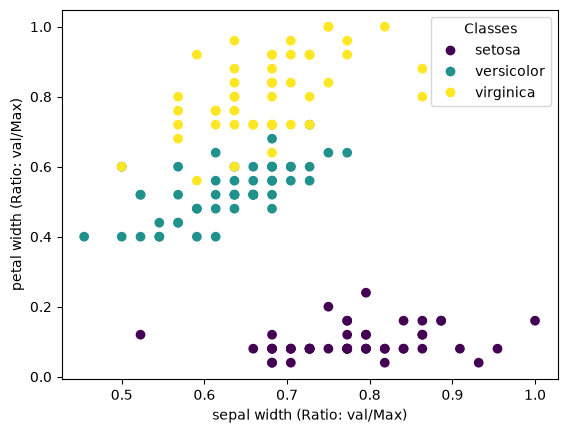

In [98]:
x_axis_label = 'sepal width (cm)'
y_axis_label = 'petal width (cm)'

x_axis_data = df[x_axis_label]
y_axis_data = df[y_axis_label]

xMax = x_axis_data.max()
yMax = y_axis_data.max()

for i in range(len(x_axis_data)):
    x_axis_data[i] = x_axis_data[i]/xMax
    y_axis_data[i] = y_axis_data[i]/yMax

fig, ax = plt.subplots()
scatter = ax.scatter(x_axis_data, y_axis_data, c=y)
ax.set_xlabel(x_axis_label[:-4]+'(Ratio: val/Max)')
ax.set_ylabel(y_axis_label[:-4]+'(Ratio: val/Max)')
fig = ax.legend(scatter.legend_elements()[0], iris.target_names, loc="best", title="Classes")
plt.show()

In [108]:
n_sample = len(x_axis_data)

data1 = np.array(x_axis_data)
data2 = np.array(y_axis_data)

centeredData1 = data1 - data1.mean()
centeredData2 = data2 - data2.mean()

cDataT = np.array([centeredData1, centeredData2])
cData = cDataT.transpose()

covMatrix = (cDataT @ cData)/n_sample
eigenValues, eigenVectors = np.linalg.eig(covMatrix)

print('Covariance Matrix:')
print(covMatrix)

print('\nEigenvalues:')
print(eigenValues)

print('\nEigenvectors (as columns):')
print(eigenVectors)

maxEigenValue = eigenValues[0]
maxEigenValueIndex = 0
for i in range(len(eigenValues)):
    if eigenValues[i] > maxEigenValue:
        maxEigenValue = eigenValues[i]
        maxEigenValueIndex = i
        
maxEigenVector = eigenVectors[:,i]

print('\nMax Eigenvalue:',maxEigenValue, '| Corresponding Eigenvector:',maxEigenVector)

Covariance Matrix:
[[ 0.00974757 -0.0109844 ]
 [-0.0109844   0.09234126]]

Eigenvalues:
[0.00831168 0.09377715]

Eigenvectors (as columns):
[[-0.99156401  0.12961792]
 [-0.12961792 -0.99156401]]

Max Eigenvalue: 0.09377715093968823 | Corresponding Eigenvector: [ 0.12961792 -0.99156401]


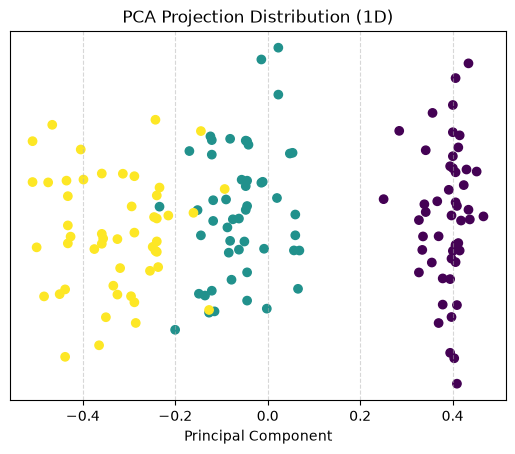

In [148]:
projectedData = cData @ maxEigenVector

jitter = np.random.normal(0, 0.01, size=len(projectedData)) 

fig, ax = plt.subplots()
ax.scatter(projectedData, jitter, c=y)
ax.set_xlabel('Principal Component')
ax.get_yaxis().set_visible(False)
ax.set_title('PCA Projection Distribution (1D)')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()